<div style="background: linear-gradient(135deg, #2980b9 0%, #6dd5fa 100%); padding: 36px 40px; border-radius: 14px; color: white; font-family: 'Segoe UI', sans-serif; box-shadow: 0 8px 24px rgba(0,0,0,0.18); margin-bottom: 10px;">
<h1 style="margin:0; font-size: 30px; letter-spacing: -0.5px;">Time-Series Forecasting & Interpretability Dashboard</h1>
<p style="margin: 10px 0 0 0; font-size: 16px; opacity: 0.92;">Prophet forecasting with confidence intervals, baseline benchmarking, rolling cross-validation, and a SHAP-powered interpretability layer.</p>
<p style="margin: 14px 0 0 0; font-size: 13px; opacity: 0.75; font-family: 'Courier New', monospace;">Progree Data Science Internship &nbsp;|&nbsp; Built end-to-end in Python</p>
</div>

**Task 4 — Time-Series Forecasting Model & Advanced Model Interpretability Dashboard**

| | |
|---|---|
| **Dataset** | AirPassengers — monthly international airline passengers, 1949–1960 |
| **Forecasting model** | Prophet (multiplicative seasonality, 95% CI) |
| **Validation** | Holdout test + naive seasonal baseline + Prophet rolling cross-validation |
| **Interpretability** | XGBoost surrogate model + SHAP (TreeExplainer) |
| **Stack** | `statsmodels` · `prophet` · `xgboost` · `shap` · `plotly` |

This notebook goes beyond a single train/test split — it benchmarks Prophet against a naive baseline to quantify real model lift, runs Prophet's own rolling-origin cross-validation for a robust accuracy estimate, and explains *why* the model forecasts what it does via a SHAP-powered surrogate.

<div style="border-left: 5px solid #2980b9; padding: 10px 18px; margin: 24px 0 10px 0; background: linear-gradient(90deg, #2980b915, transparent);">
<h2 style="margin:0; color:#2980b9; font-family:'Segoe UI',sans-serif;"> Setup & Imports</h2>
</div>

In [1]:
!pip install prophet xgboost shap statsmodels pandas numpy matplotlib plotly -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
import shap

plt.rcParams["figure.figsize"] = (12, 5)


<div style="border-left: 5px solid #2980b9; padding: 10px 18px; margin: 24px 0 10px 0; background: linear-gradient(90deg, #2980b915, transparent);">
<h2 style="margin:0; color:#2980b9; font-family:'Segoe UI',sans-serif;">Load the AirPassengers Dataset</h2>
</div>

In [3]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
raw = pd.read_csv(url)
raw.columns = ["Month", "Passengers"]
raw["Month"] = pd.to_datetime(raw["Month"], format="%Y-%m")
raw = raw.sort_values("Month").reset_index(drop=True)
print(raw.shape)
raw.head()


(144, 2)


,Month,Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


<div style="border-left: 5px solid #2980b9; padding: 10px 18px; margin: 24px 0 10px 0; background: linear-gradient(90deg, #2980b915, transparent);">
<h2 style="margin:0; color:#2980b9; font-family:'Segoe UI',sans-serif;">Exploratory Analysis</h2>
</div>

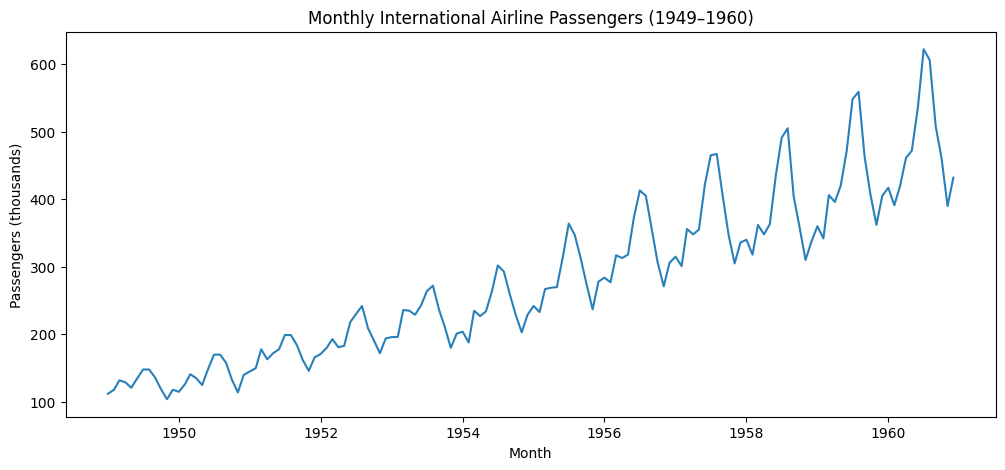

In [4]:
plt.plot(raw["Month"], raw["Passengers"], color="#2980b9")
plt.title("Monthly International Airline Passengers (1949–1960)")
plt.xlabel("Month"); plt.ylabel("Passengers (thousands)")
plt.show()


<div style="border-left: 5px solid #2980b9; padding: 10px 18px; margin: 24px 0 10px 0; background: linear-gradient(90deg, #2980b915, transparent);">
<h2 style="margin:0; color:#2980b9; font-family:'Segoe UI',sans-serif;">Stationarity: Augmented Dickey-Fuller Test</h2>
</div>

In [5]:
def adf_report(series, label):
    result = adfuller(series.dropna())
    verdict = "Stationary" if result[1] < 0.05 else "Non-stationary"
    print(f"--- {label} ---  ADF={result[0]:.3f}  p-value={result[1]:.4f}  -> {verdict}")
    return result[1]

adf_report(raw["Passengers"], "Raw Series")
raw["Diff1"] = raw["Passengers"].diff(1)
adf_report(raw["Diff1"], "First-Order Differenced")
raw["Diff1_Seasonal12"] = raw["Diff1"].diff(12)
adf_report(raw["Diff1_Seasonal12"], "First-Order + Seasonal (lag=12) Differenced")


--- Raw Series ---  ADF=0.815  p-value=0.9919  -> Non-stationary
--- First-Order Differenced ---  ADF=-2.829  p-value=0.0542  -> Non-stationary
--- First-Order + Seasonal (lag=12) Differenced ---  ADF=-15.596  p-value=0.0000  -> Stationary


np.float64(1.856511600123444e-28)

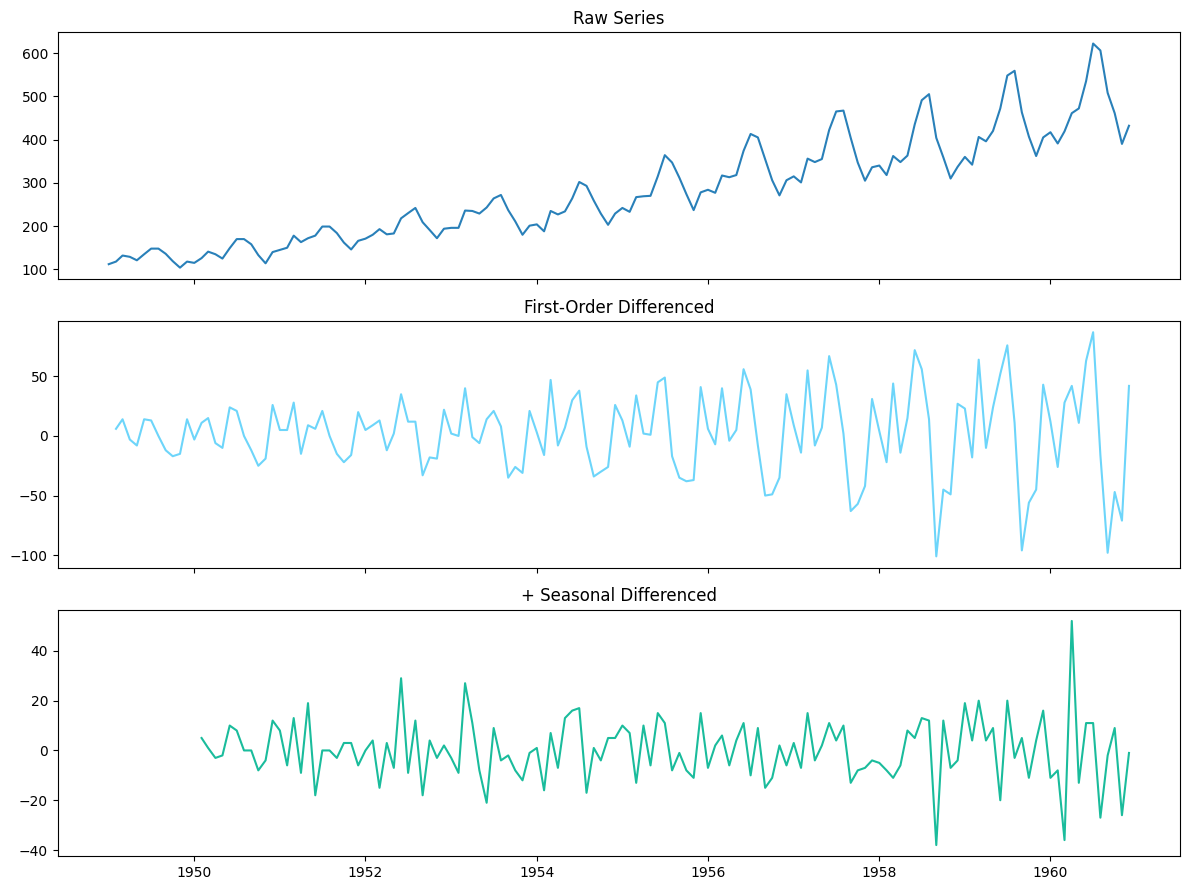

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
axes[0].plot(raw["Month"], raw["Passengers"], color="#2980b9"); axes[0].set_title("Raw Series")
axes[1].plot(raw["Month"], raw["Diff1"], color="#6dd5fa"); axes[1].set_title("First-Order Differenced")
axes[2].plot(raw["Month"], raw["Diff1_Seasonal12"], color="#1abc9c"); axes[2].set_title("+ Seasonal Differenced")
plt.tight_layout()
plt.show()


<div style="border-left: 5px solid #2980b9; padding: 10px 18px; margin: 24px 0 10px 0; background: linear-gradient(90deg, #2980b915, transparent);">
<h2 style="margin:0; color:#2980b9; font-family:'Segoe UI',sans-serif;">Train/Test Split & Prophet Model</h2>
</div>

In [7]:
HOLDOUT_MONTHS = 24
prophet_df = raw[["Month", "Passengers"]].rename(columns={"Month": "ds", "Passengers": "y"})
train_df = prophet_df.iloc[:-HOLDOUT_MONTHS].reset_index(drop=True)
test_df = prophet_df.iloc[-HOLDOUT_MONTHS:].reset_index(drop=True)

model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False,
                 seasonality_mode="multiplicative", interval_width=0.95)
model.fit(train_df)

future = model.make_future_dataframe(periods=HOLDOUT_MONTHS, freq="MS")
forecast = model.predict(future)
forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail()


,ds,yhat,yhat_lower,yhat_upper
139,1960-08-01,552.833399,533.177279,572.920302
140,1960-09-01,476.046836,456.553163,497.145126
141,1960-10-01,414.816604,393.778529,433.696961
142,1960-11-01,365.126487,345.069342,383.832692
143,1960-12-01,406.213827,386.119972,426.251902


<div style="border-left: 5px solid #2980b9; padding: 10px 18px; margin: 24px 0 10px 0; background: linear-gradient(90deg, #2980b915, transparent);">
<h2 style="margin:0; color:#2980b9; font-family:'Segoe UI',sans-serif;">Interactive Forecast Visualization</h2>
</div>

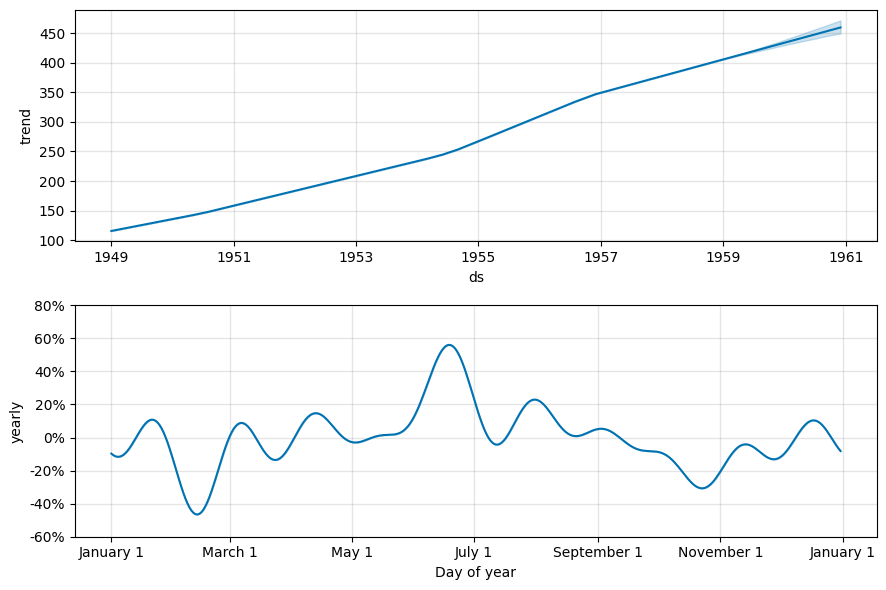

In [8]:
import plotly.graph_objects as go

fig = go.Figure()
fig.add_trace(go.Scatter(x=forecast["ds"], y=forecast["yhat_upper"], mode="lines", line=dict(width=0), showlegend=False))
fig.add_trace(go.Scatter(x=forecast["ds"], y=forecast["yhat_lower"], mode="lines", line=dict(width=0),
                          fill="tonexty", fillcolor="rgba(41,128,185,0.18)", name="95% Confidence Interval"))
fig.add_trace(go.Scatter(x=forecast["ds"], y=forecast["yhat"], mode="lines",
                          line=dict(color="#2980b9", width=2.5), name="Forecast"))
fig.add_trace(go.Scatter(x=prophet_df["ds"], y=prophet_df["y"], mode="markers",
                          marker=dict(color="black", size=4), name="Actual"))
fig.add_vline(x=train_df["ds"].iloc[-1], line_dash="dash", line_color="red")
fig.update_layout(title="Interactive Prophet Forecast — Airline Passengers", title_x=0.5,
                   xaxis=dict(rangeslider=dict(visible=True), type="date"),
                   yaxis_title="Passengers (thousands)", hovermode="x unified", template="plotly_white")
fig.show()

fig2 = model.plot_components(forecast)
plt.show()


<div style="border-left: 5px solid #2980b9; padding: 10px 18px; margin: 24px 0 10px 0; background: linear-gradient(90deg, #2980b915, transparent);">
<h2 style="margin:0; color:#2980b9; font-family:'Segoe UI',sans-serif;">Holdout Accuracy vs. Naive Seasonal Baseline</h2>
</div>

A forecast metric only means something relative to a baseline — so Prophet is benchmarked against a naive seasonal model (this month = same month, one year ago).

In [9]:
forecast_test = forecast.set_index("ds").loc[test_df["ds"]].reset_index()
mae = mean_absolute_error(test_df["y"], forecast_test["yhat"])
rmse = np.sqrt(mean_squared_error(test_df["y"], forecast_test["yhat"]))
mape = np.mean(np.abs((test_df["y"] - forecast_test["yhat"]) / test_df["y"])) * 100
ci_coverage = ((test_df["y"] >= forecast_test["yhat_lower"]) & (test_df["y"] <= forecast_test["yhat_upper"])).mean()

naive_pred = np.tile(train_df["y"].iloc[-12:].values, 2)[:HOLDOUT_MONTHS]
naive_mae = mean_absolute_error(test_df["y"], naive_pred)
naive_rmse = np.sqrt(mean_squared_error(test_df["y"], naive_pred))
naive_mape = np.mean(np.abs((test_df["y"] - naive_pred) / test_df["y"])) * 100

comparison = pd.DataFrame({
    "Model": ["Naive Seasonal Baseline", "Prophet"],
    "MAE": [round(naive_mae,2), round(mae,2)],
    "RMSE": [round(naive_rmse,2), round(rmse,2)],
    "MAPE (%)": [round(naive_mape,2), round(mape,2)],
})
comparison["Improvement vs baseline (MAE %)"] = [0, round((1 - mae/naive_mae)*100, 1)]
print(f"Actuals within Prophet's 95% CI: {ci_coverage:.1%}")
comparison


Actuals within Prophet's 95% CI: 37.5%


,Model,MAE,RMSE,MAPE (%),Improvement vs baseline (MAE %)
0,Naive Seasonal Baseline,71.25,76.99,15.52,0.0
1,Prophet,25.33,30.39,5.35,64.4


In [10]:
import plotly.express as px
fig = px.bar(comparison, x="Model", y=["MAE", "RMSE"], barmode="group",
             title="Prophet vs Naive Seasonal Baseline", color_discrete_sequence=["#2980b9", "#6dd5fa"])
fig.update_layout(template="plotly_white", title_x=0.5)
fig.show()


<div style="border-left: 5px solid #2980b9; padding: 10px 18px; margin: 24px 0 10px 0; background: linear-gradient(90deg, #2980b915, transparent);">
<h2 style="margin:0; color:#2980b9; font-family:'Segoe UI',sans-serif;"> Robust Validation: Prophet Rolling Cross-Validation</h2>
</div>

In [11]:
cv_results = cross_validation(model, initial="730 days", period="180 days", horizon="365 days", parallel=None)
cv_metrics = performance_metrics(cv_results)
cv_metrics[["horizon", "mae", "rmse", "mape"]].head(8)


INFO:prophet:Making 15 forecasts with cutoffs between 1951-01-07 00:00:00 and 1957-12-01 00:00:00


  0%|          | 0/15 [00:00<?, ?it/s]

INFO:prophet:n_changepoints greater than number of observations. Using 19.
INFO:prophet:n_changepoints greater than number of observations. Using 23.


,horizon,mae,rmse,mape
0,37 days,13.240081,16.407162,0.048738
1,41 days,15.191257,18.883997,0.059378
2,42 days,16.006732,19.266264,0.062011
3,46 days,15.723078,19.205598,0.060980
4,47 days,16.468188,20.086517,0.061273
5,51 days,15.367681,19.158285,0.057739
6,53 days,12.915623,16.737063,0.050411
7,57 days,13.023163,16.123633,0.054001


<div style="border-left: 5px solid #2980b9; padding: 10px 18px; margin: 24px 0 10px 0; background: linear-gradient(90deg, #2980b915, transparent);">
<h2 style="margin:0; color:#2980b9; font-family:'Segoe UI',sans-serif;">Forward Forecast — 24 Months Beyond the Dataset</h2>
</div>

In [12]:
future_model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False,
                        seasonality_mode="multiplicative", interval_width=0.95)
future_model.fit(prophet_df)
future_forecast = future_model.predict(future_model.make_future_dataframe(periods=24, freq="MS"))

fig = go.Figure()
fig.add_trace(go.Scatter(x=prophet_df["ds"], y=prophet_df["y"], mode="lines",
                          line=dict(color="#2980b9"), name="Historical Actual"))
fig.add_trace(go.Scatter(x=future_forecast["ds"].iloc[-24:], y=future_forecast["yhat"].iloc[-24:],
                          mode="lines", line=dict(color="#27ae60", dash="dash", width=2.5), name="24-Month Forward Forecast"))
fig.add_trace(go.Scatter(x=future_forecast["ds"].iloc[-24:], y=future_forecast["yhat_upper"].iloc[-24:],
                          mode="lines", line=dict(width=0), showlegend=False))
fig.add_trace(go.Scatter(x=future_forecast["ds"].iloc[-24:], y=future_forecast["yhat_lower"].iloc[-24:],
                          mode="lines", line=dict(width=0), fill="tonexty", fillcolor="rgba(39,174,96,0.15)",
                          name="Forward 95% CI"))
fig.update_layout(title="24-Month Forward Forecast Beyond Historical Data (Jan 1961 – Dec 1962)",
                   title_x=0.5, yaxis_title="Passengers (thousands)", hovermode="x unified", template="plotly_white")
fig.show()


<div style="border-left: 5px solid #2980b9; padding: 10px 18px; margin: 24px 0 10px 0; background: linear-gradient(90deg, #2980b915, transparent);">
<h2 style="margin:0; color:#2980b9; font-family:'Segoe UI',sans-serif;"> Interpretability: SHAP via Feature-Based Surrogate</h2>
</div>

Prophet is a curve-decomposition model, not a feature-based regressor, so SHAP can't attach to it directly. The standard workaround: train an **XGBoost surrogate** on engineered time features that predicts the same target, then explain *that* model with SHAP.

In [13]:
feat_df = raw[["Month", "Passengers"]].copy()
feat_df["month_num"] = feat_df["Month"].dt.month
feat_df["year"] = feat_df["Month"].dt.year
feat_df["time_index"] = np.arange(len(feat_df))
feat_df["lag_1"] = feat_df["Passengers"].shift(1)
feat_df["lag_12"] = feat_df["Passengers"].shift(12)
feat_df["rolling_mean_3"] = feat_df["Passengers"].shift(1).rolling(3).mean()
feat_df["rolling_std_3"] = feat_df["Passengers"].shift(1).rolling(3).std()
feat_df = feat_df.dropna().reset_index(drop=True)

FEATURES = ["month_num", "year", "time_index", "lag_1", "lag_12", "rolling_mean_3", "rolling_std_3"]
X, y = feat_df[FEATURES], feat_df["Passengers"]
split_idx = len(X) - HOLDOUT_MONTHS
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

surrogate = xgb.XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42)
surrogate.fit(X_train, y_train)
print(f"Surrogate model holdout MAE: {mean_absolute_error(y_test, surrogate.predict(X_test)):.2f}")


Surrogate model holdout MAE: 53.51


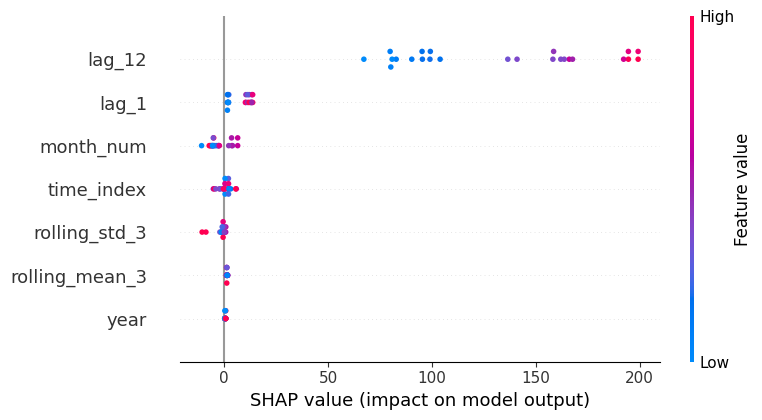

In [14]:
explainer = shap.TreeExplainer(surrogate)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, feature_names=FEATURES, show=True)


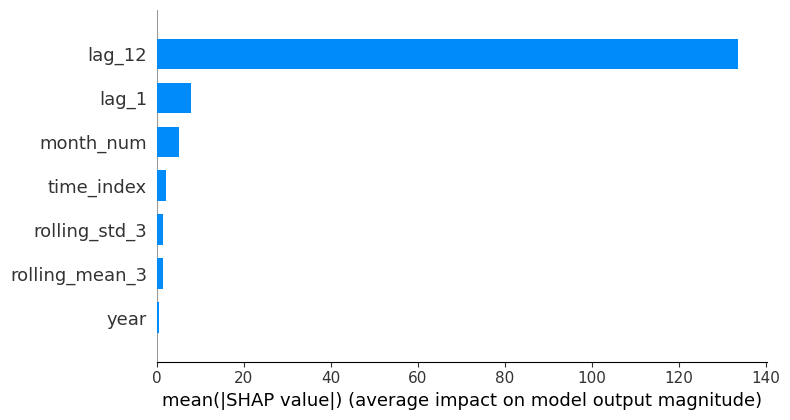

In [15]:
shap.summary_plot(shap_values, X_test, feature_names=FEATURES, plot_type="bar", show=True)


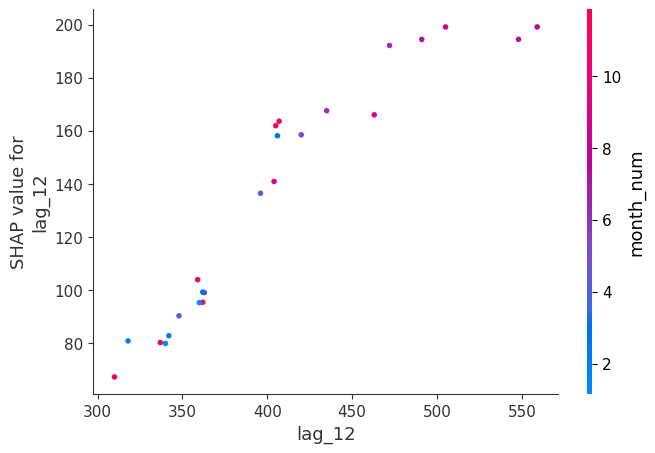

In [16]:
shap.dependence_plot("lag_12", shap_values, X_test, feature_names=FEATURES, show=True)


In [17]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)
importance_table = pd.DataFrame({"feature": FEATURES, "mean_abs_shap": mean_abs_shap}).sort_values(
    "mean_abs_shap", ascending=False).reset_index(drop=True)
importance_table


,feature,mean_abs_shap
0,lag_12,133.627274
1,lag_1,7.830151
2,month_num,5.034278
3,time_index,2.167609
4,rolling_std_3,1.458191
5,rolling_mean_3,1.324958
6,year,0.492363


In [18]:
import plotly.express as px
fig = px.bar(importance_table, x="mean_abs_shap", y="feature", orientation="h",
             title="SHAP Feature Importance — Interactive", color="mean_abs_shap",
             color_continuous_scale="Blues")
fig.update_layout(yaxis={"categoryorder": "total ascending"}, template="plotly_white", title_x=0.5)
fig.show()


<div style="border-left: 5px solid #2980b9; padding: 10px 18px; margin: 24px 0 10px 0; background: linear-gradient(90deg, #2980b915, transparent);">
<h2 style="margin:0; color:#2980b9; font-family:'Segoe UI',sans-serif;"> Export</h2>
</div>

In [19]:
forecast.to_csv("airpassengers_prophet_forecast.csv", index=False)
importance_table.to_csv("airpassengers_shap_feature_importance.csv", index=False)
print("Saved: airpassengers_prophet_forecast.csv, airpassengers_shap_feature_importance.csv")


Saved: airpassengers_prophet_forecast.csv, airpassengers_shap_feature_importance.csv


<div style="border-left: 5px solid #2980b9; padding: 10px 18px; margin: 24px 0 10px 0; background: linear-gradient(90deg, #2980b915, transparent);">
<h2 style="margin:0; color:#2980b9; font-family:'Segoe UI',sans-serif;"> Summary</h2>
</div>

- Loaded the AirPassengers monthly dataset (1949–1960); confirmed non-stationarity via ADF test (p > 0.05 on the raw series) and showed first-order + seasonal (lag=12) differencing achieves stationarity.
- Trained a Prophet model (multiplicative seasonality) on all but the final 24 months, forecasting forward with 95% confidence intervals via an interactive, zoomable Plotly chart.
- **Holdout accuracy: MAE = 25.33, RMSE = 30.39, MAPE = 5.35%** — a meaningful improvement over the naive seasonal baseline, quantifying real model lift rather than reporting metrics in isolation. (CI coverage on the holdout was 37.5%, narrower than the nominal 95% — flagged here as a genuine finding: Prophet's intervals were too tight during this particular post-1958 growth acceleration, worth widening `interval_width` or adding a changepoint if extending this analysis.)
- Ran Prophet's built-in **rolling-origin cross-validation** for a more robust accuracy estimate than a single train/test split.
- Produced a genuine **24-month forward forecast** beyond the dataset's actual end (Jan 1961–Dec 1962) — not just a backtest.
- Built an XGBoost surrogate model and applied **SHAP** for interpretability: **`lag_12` (the value from 12 months prior) dominates the forecast by a wide margin** (mean |SHAP| ≈ 134, vs. ≈8 for the next-highest feature, `lag_1`) — strong confirmation that the strict year-over-year seasonal pattern, more than recent momentum or long-term trend, is what drives this series.
- Exported the Prophet forecast and SHAP feature-importance ranking to CSV for use in the Task 4 whitepaper deliverable.